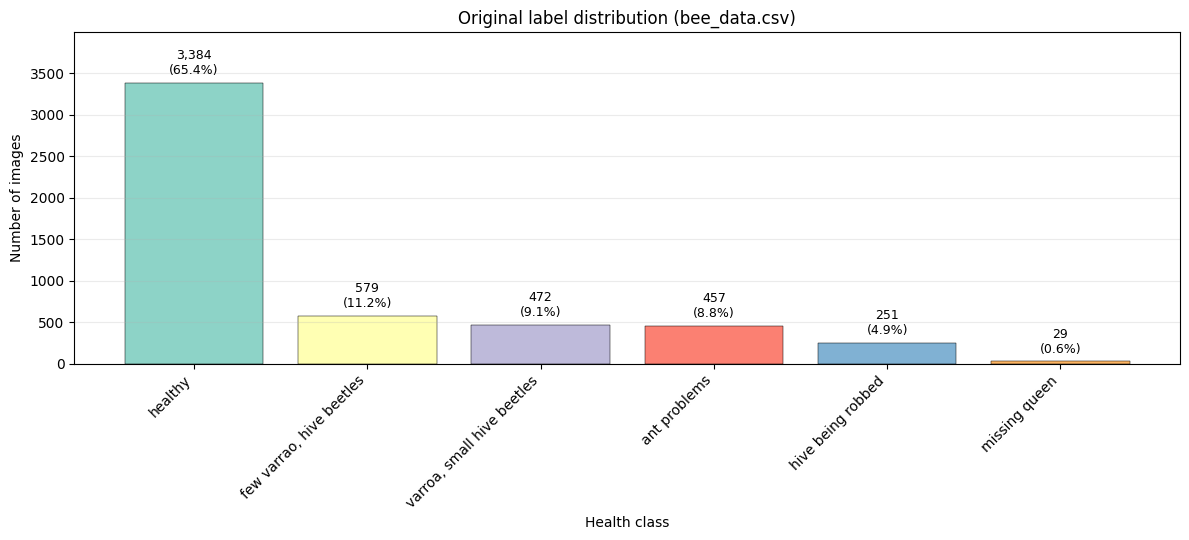

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

raw_df = pd.read_csv("../data/raw/bee_data.csv")
raw_health = raw_df["health"].astype(str).str.strip().str.lower()
raw_counts = raw_health.value_counts().sort_values(ascending=False)

raw_total = raw_counts.sum()
max_count = raw_counts.max()
label_offset = max_count * 0.02

plt.figure(figsize=(12, 5.5))
bar_colors = plt.cm.Set3(range(len(raw_counts)))
bars = plt.bar(raw_counts.index, raw_counts.values, color=bar_colors, edgecolor="black", linewidth=0.35)

for bar, count in zip(bars, raw_counts.values):
    pct = (count / raw_total) * 100 if raw_total else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + label_offset,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.title("Original label distribution (bee_data.csv)")
plt.ylabel("Number of images")
plt.xlabel("Health class")
plt.ylim(0, max_count * 1.18)
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

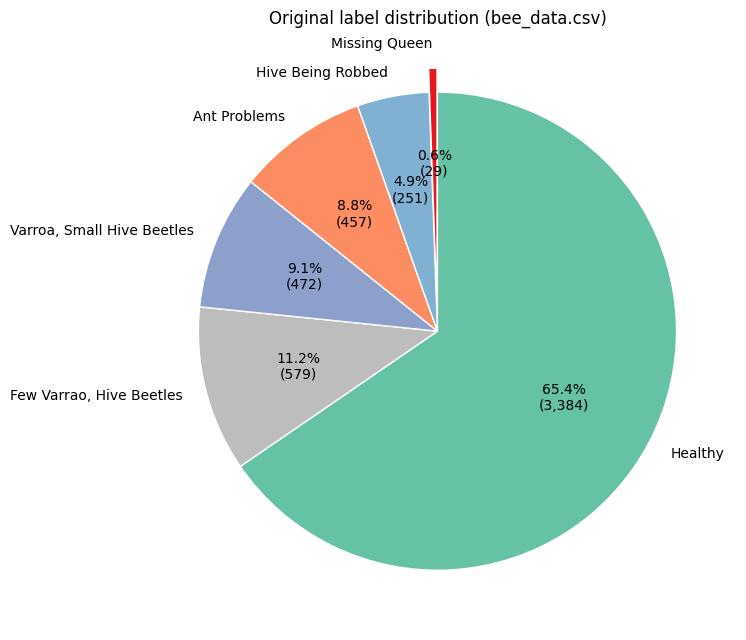

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

raw_df = pd.read_csv("../data/raw/bee_data.csv")
raw_health = raw_df["health"].astype(str).str.strip().str.lower()
raw_counts = raw_health.value_counts().sort_values(ascending=False)

pie_labels = [label.title() for label in raw_counts.index]

# High-contrast colors for clearer slice separation, with special emphasis on 'missing queen'
color_map = {
    "healthy": "#66c2a5",
    "few varroa, hive beetles": "#ffd92f",
    "varroa, small hive beetles": "#8da0cb",
    "ant problems": "#fc8d62",
    "hive being robbed": "#80b1d3",
    "missing queen": "#e41a1c",
}
pie_colors = [color_map.get(cls, "#bdbdbd") for cls in raw_counts.index]

# Slightly separate tiny slices so they are easier to spot
total_count = raw_counts.sum()
explode = [0.10 if (count / total_count) < 0.02 else 0.0 for count in raw_counts.values]

def autopct_with_count(values):
    total = sum(values)
    def _formatter(pct):
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count:,})"
    return _formatter

plt.figure(figsize=(8.5, 6.5))
plt.pie(
    raw_counts.values,
    labels=pie_labels,
    colors=pie_colors,
    explode=explode,
    autopct=autopct_with_count(raw_counts.values),
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 10},
)
plt.title("Original label distribution (bee_data.csv)")
plt.tight_layout()
plt.show()

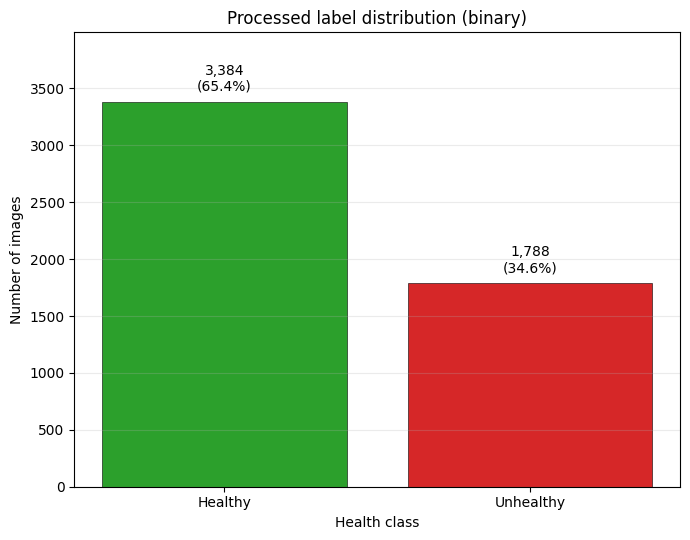

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

processed_df = pd.read_csv("../data/processed/processed_bee_data_20260330_151740.csv", sep=";")

binary_counts = (
    processed_df["health"]
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
    .reindex(["healthy", "unhealthy"])
    .fillna(0)
    .astype(int)
)

binary_total = binary_counts.sum()
max_count = binary_counts.max()
label_offset = max_count * 0.02

plt.figure(figsize=(7, 5.5))
binary_labels = [label.title() for label in binary_counts.index]
binary_colors = ["#2ca02c", "#d62728"]
bars = plt.bar(binary_labels, binary_counts.values, color=binary_colors, edgecolor="black", linewidth=0.4)

for bar, count in zip(bars, binary_counts.values):
    pct = (count / binary_total) * 100 if binary_total else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + label_offset,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.title("Processed label distribution (binary)")
plt.ylabel("Number of images")
plt.xlabel("Health class")
plt.ylim(0, max_count * 1.18)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

CNN: 
Summary metrics (positive class = unhealthy): 
Accuracy: 0.9768 
Precision: 0.9665 
Recall: 0.9665 
F1-score: 0.9665 
ROC AUC: 0.9962

Random Forest: 
Summary metrics (positive class = unhealthy): 
Accuracy: 0.9208 
Precision: 0.9313 
Recall: 0.8324 
F1-score: 0.8791 
ROC-AUC: 0.9806

SVM: 
Summary metrics (positive class = unhealthy): 
Accuracy: 0.9151 
Precision: 0.9091 
Recall: 0.8380 
F1-score: 0.8721 
ROC-AUC: 0.9686

Hybrid
Summary metrics (positive class = unhealthy):
Accuracy:  0.9749
Precision: 0.9663
Recall:    0.9609
F1-score:  0.9636
ROC-AUC:   0.9916

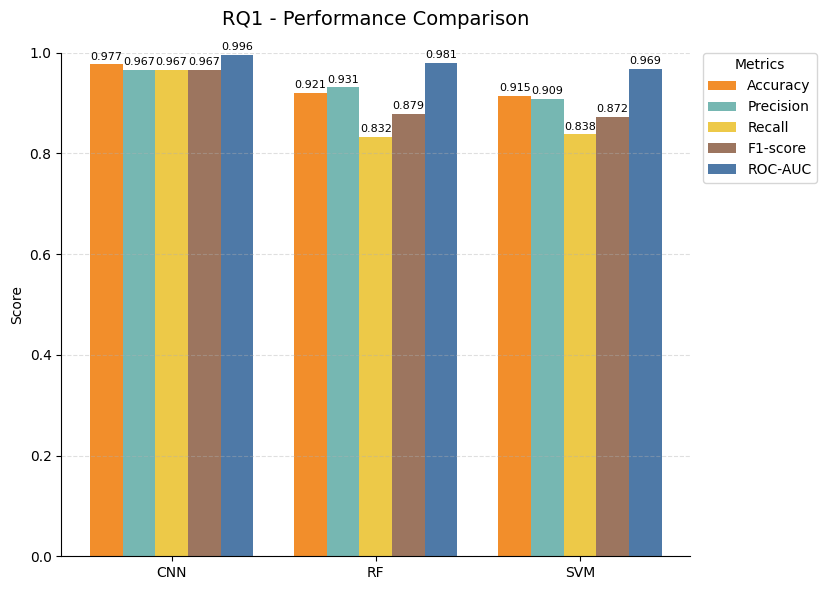

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Include ROC-AUC in the comparison plot
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
model_names = ["CNN", "RF", "SVM"]
scores = {
    "Accuracy": [0.9768, 0.9208, 0.9151],
    "Precision": [0.9665, 0.9313, 0.9091],
    "Recall": [0.9665, 0.8324, 0.8380],
    "F1-score": [0.9665, 0.8791, 0.8721],
    "ROC-AUC": [0.9962, 0.9806, 0.9686]
}

# Colorblind-friendly palette avoiding red-green and blue-purple pairs
metric_colors = ["#F28E2B", "#76B7B2", "#EDC948", "#9C755F", "#4E79A7"]

x = np.arange(len(model_names))
width = 0.16

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    bars = ax.bar(
        x + (i - (len(metrics) - 1) / 2) * width,
        scores[metric],
        width,
        label=metric,
        color=metric_colors[i],
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

ax.set_title("RQ1 - Performance Comparison", pad=20, fontsize=14)
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.00)
ax.legend(title="Metrics", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

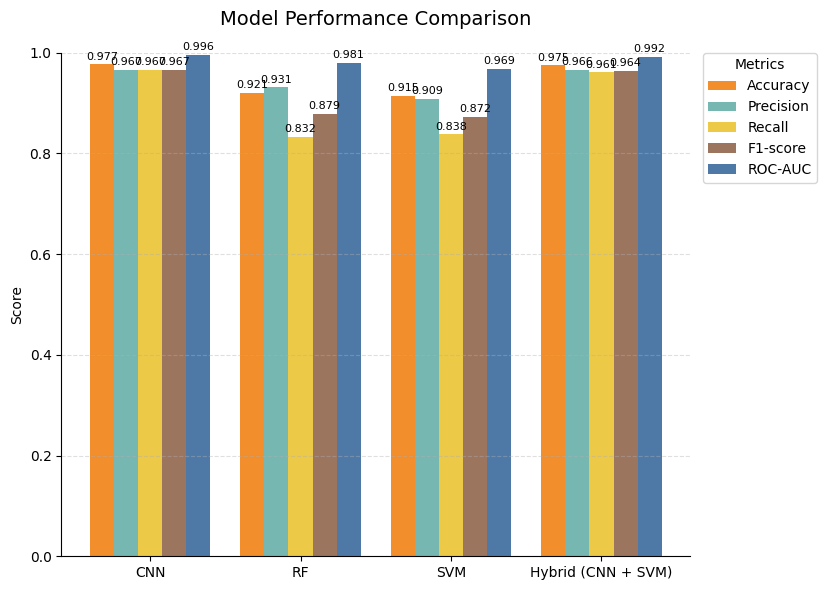

In [31]:
import matplotlib.pyplot as plt
import numpy as np
# library imports added redundantly to be able to run cells separately

# Include ROC-AUC in the comparison plot
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
model_names = ["CNN", "RF", "SVM", "Hybrid (CNN + SVM)"]
scores = {
    "Accuracy": [0.9768, 0.9208, 0.9151, 0.9749],
    "Precision": [0.9665, 0.9313, 0.9091, 0.9663],
    "Recall": [0.9665, 0.8324, 0.8380, 0.9609],
    "F1-score": [0.9665, 0.8791, 0.8721, 0.9636],
    "ROC-AUC": [0.9962, 0.9806, 0.9686, 0.9916],
}

# Colorblind-friendly palette avoiding red-green and blue-purple pairs
metric_colors = ["#F28E2B", "#76B7B2", "#EDC948", "#9C755F", "#4E79A7"]

x = np.arange(len(model_names))
width = 0.16

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    bars = ax.bar(
        x + (i - (len(metrics) - 1) / 2) * width,
        scores[metric],
        width,
        label=metric,
        color=metric_colors[i],
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

ax.set_title("Model Performance Comparison", pad=20, fontsize=14)
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.00)
ax.legend(title="Metrics", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

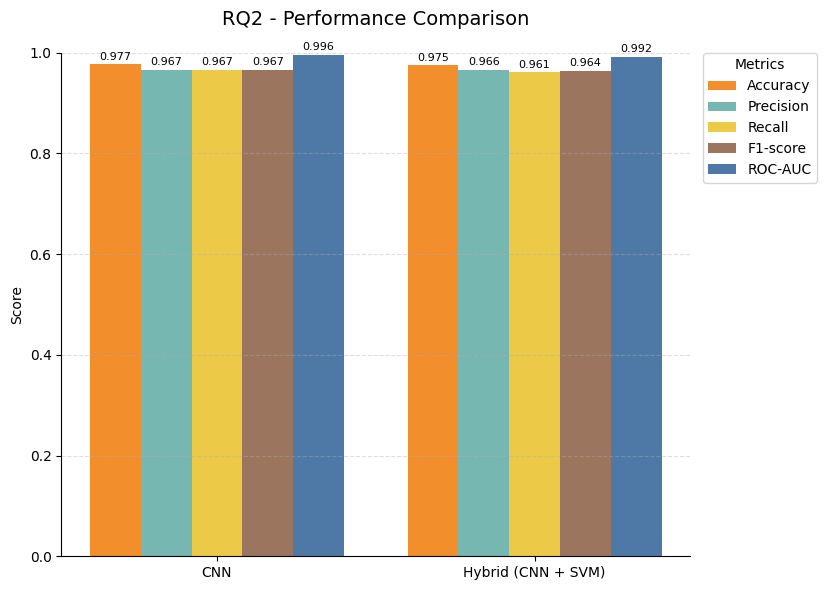

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Include ROC-AUC in the comparison plot
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
model_names = ["CNN", "Hybrid (CNN + SVM)"]
scores = {
    "Accuracy": [0.9768, 0.9749],
    "Precision": [0.9665, 0.9663],
    "Recall": [0.9665, 0.9609],
    "F1-score": [0.9665, 0.9636],
    "ROC-AUC": [0.9962, 0.9916]
}

# Colorblind-friendly palette
metric_colors = ["#F28E2B", "#76B7B2", "#EDC948", "#9C755F", "#4E79A7"]

x = np.arange(len(model_names))
width = 0.16

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    bars = ax.bar(
        x + (i - (len(metrics) - 1) / 2) * width,
        scores[metric],
        width,
        label=metric,
        color=metric_colors[i],
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

ax.set_title("RQ2 - Performance Comparison", pad=20, fontsize=14)
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.00)
ax.legend(title="Metrics", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

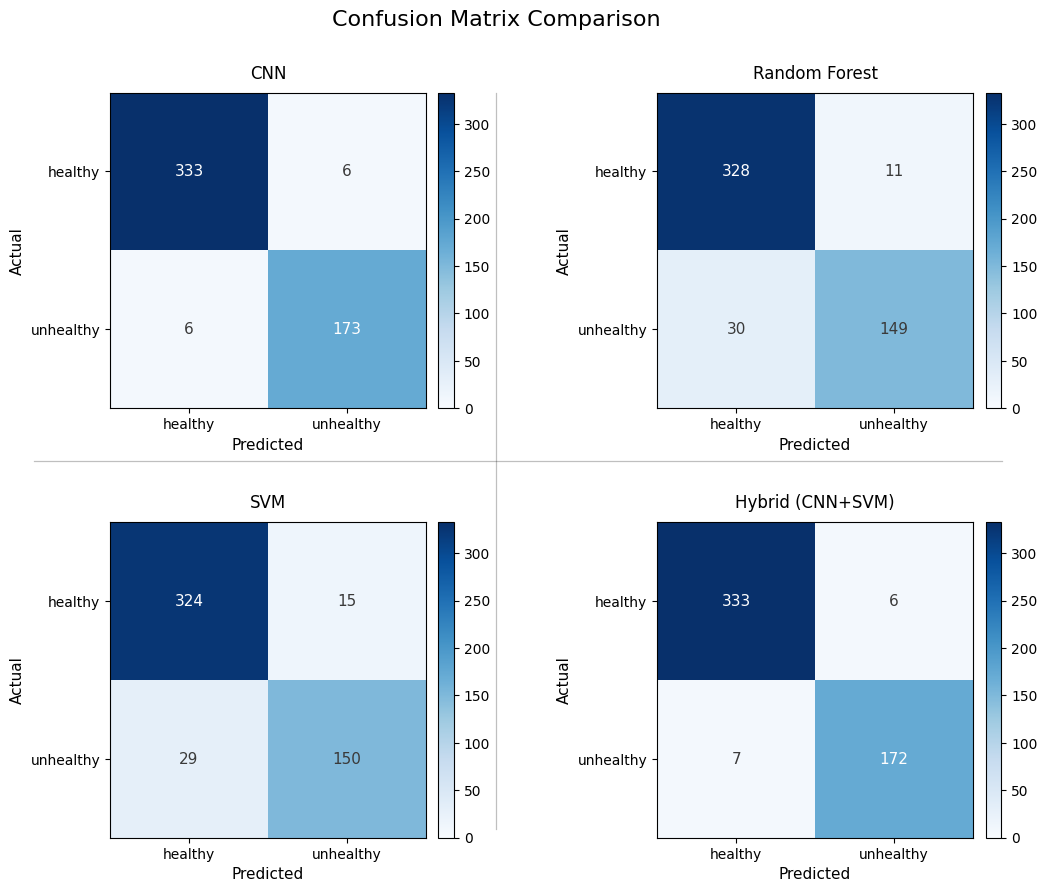

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Confusion matrices in the form: [[TN, FP], [FN, TP]]
conf_mats = {
    "CNN": np.array([[333, 6], [6, 173]]),
    "Random Forest": np.array([[328, 11], [30, 149]]),
    "SVM": np.array([[324, 15], [29, 150]]),
    "Hybrid (CNN+SVM)": np.array([[333, 6], [7, 172]]),
}

labels = ["healthy", "unhealthy"]
vmax = max(matrix.max() for matrix in conf_mats.values())

# Create 2x2 canvas
fig, axes = plt.subplots(2, 2, figsize=(11, 9.2))
axes = axes.ravel()

# Panel order
panel_titles = ["CNN", "Random Forest", "SVM", "Hybrid (CNN+SVM)"]

def draw_matrix(ax, title, matrix):
    """Draw one confusion matrix panel."""
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=vmax)

    # Write values inside cells
    for r in range(2):
        for c in range(2):
            value = matrix[r, c]
            text_color = "white" if value > vmax * 0.5 else "#3a3a3a"
            ax.text(c, r, f"{value}", ha="center", va="center", color=text_color, fontsize=11)

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

    # Keep individual colorbar style used earlier
    fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03)

# Draw all four panels
for ax, title in zip(axes, panel_titles):
    draw_matrix(ax, title, conf_mats[title])

# Figure-level title
fig.suptitle("Confusion Matrix Comparison", fontsize=16, y=0.99)

# Spacing and separator lines
fig.subplots_adjust(left=0.08, right=0.96, bottom=0.09, top=0.90, wspace=0.30, hspace=0.36)
fig.add_artist(
    Line2D([0.5, 0.5], [0.10, 0.90], transform=fig.transFigure, color="black", linewidth=0.9, alpha=0.25)
)
fig.add_artist(
    Line2D([0.08, 0.96], [0.5, 0.5], transform=fig.transFigure, color="black", linewidth=0.9, alpha=0.25)
)

plt.show()